## Spatial Filtering and Noise
Spatial operations use pixels in a neighborhood to determine the present pixel value.  
Applications include blurring, denoising and sharpening.  
They are often used to pre-processing an images and be used as a key building block in Artificial Intelligence algorithms.

This lab covers:  
> Linear Filtering\
  Filtering Noise\
  Gaussian Blur\
  Image Sharpening\
  Median filter\
  Noise 
  

In [158]:
import matplotlib.pyplot as plt
import cv2
# Used to create kernels for filtering
import numpy as np

#### Function to plot two images

In [13]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(12,12))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))
    plt.title(title_2)
    plt.show()

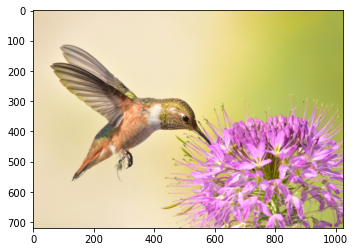

In [14]:
# Loads the image from the specified file
#image = cv2.imread("lab7/lena.png")
#print(image)
image = cv2.imread("lab7/humming.png")
# Converts the order of the color from BGR (Blue Green Red) to RGB (Red Green Blue) then renders the image from the array of data
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

### Adding Gaussian noises to the image

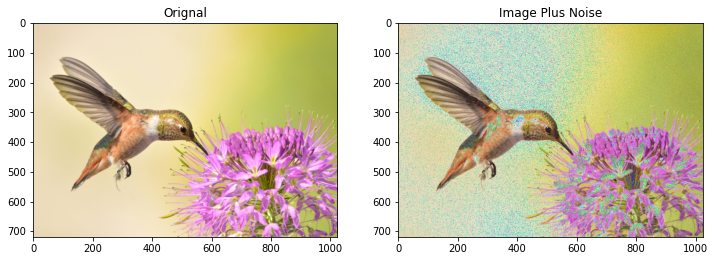

In [15]:
# Get the number of rows and columns in the image
rows, cols,_= image.shape
# Creates values using a normal distribution with a mean of 0 and standard deviation of 15, the values are converted to unit8 which means the values are between 0 and 255
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Add the noise to the image
noisy_image = image + noise
# Plots the original image and the image with noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal",title_2="Image Plus Noise")

### Convolution

The function <code>filter2D</code> performs 2D convolution between the image <code>src</code> and the  <code>kernel</code> on each color channel independently. The parameter <a href="https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkCV0101ENCoursera25797139-2022-01-01#filter_depths">ddepth</a> has to do with the size of the output image, we will set it to -1 so the input and output are the same size.

#### Smoothing images
We can creat our own filters, for example, an average filter of size 5x5 

In [16]:
# Create a kernel which is a 5 by 5 array where each value is 1/(5*5)
kernel = np.ones((5,5))/25

In [17]:
# Filters the images using the kernel
image_filtered = cv2.filter2D(src=noisy_image, ddepth=-1, kernel=kernel)

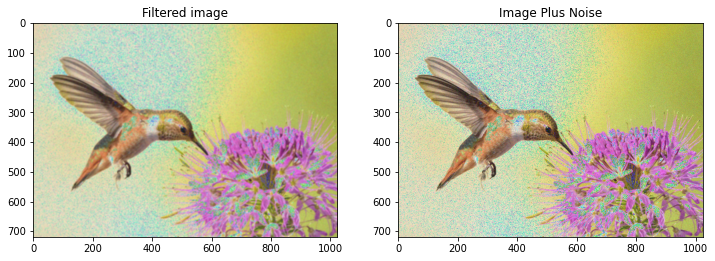

In [18]:
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Larger kernel's size captures more spatial information (a wider neighborhood are average together), 
resulting in a more pronounced blurring effect.

In [21]:
# Create a kernel which is a 9 by 9 array where each value is 1/(9*9)
kernel = np.ones((9,9))/81

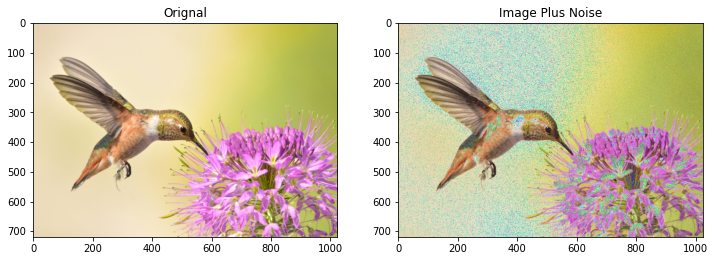

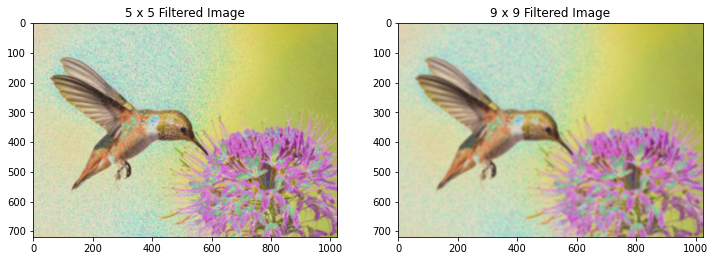

In [22]:
# Filters the images using the kernel
image_filtered_more = cv2.filter2D(src=noisy_image, ddepth=-1, kernel=kernel)
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal",title_2="Image Plus Noise")
plot_image(image_filtered, image_filtered_more,title_1="5 x 5 Filtered Image",title_2="9 x 9 Filtered Image")

### Gaussian Filter  
The most popular low-pass filter used for smoothing is the Gaussian filter; due to its smooth, bell-shaped kernel which effectively removes high-frequency noise while preserving the overall shape of the signal, making it a versatile choice for various smoothing applications across image processing and signal analysis. 

The function <code>GaussianBlur</code> convolves the source image with the specified Gaussian kernel It filters noise but does a better job of preserving the edges. It has the following parameters:

Parameters  
src input image; the image can have any number of channels, which are processed independently

ksize: Gaussian kernel size

sigmaX Gaussian kernel standard deviation in the X direction

sigmaY Gaussian kernel standard deviation in the Y direction; if sigmaY is zero, it is set to be equal to sigmaX

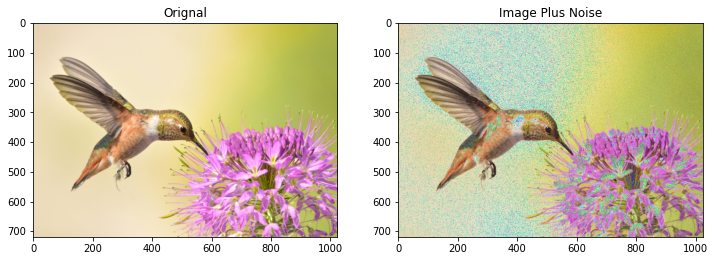

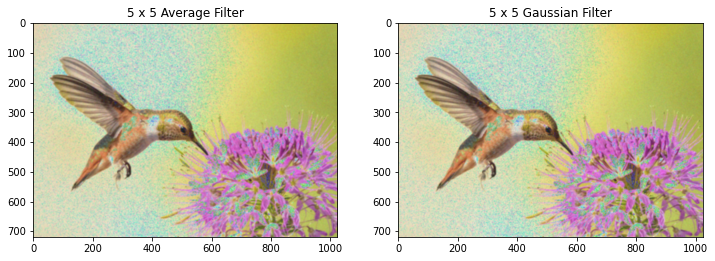

In [23]:
# Filters the images using GaussianBlur on the image with noise using a 4 by 4 kernel 
image_filtered_gauss = cv2.GaussianBlur(noisy_image,(5,5),sigmaX=3,sigmaY=3)

# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal",title_2="Image Plus Noise")
plot_image(image_filtered, image_filtered_gauss,title_1="5 x 5 Average Filter",title_2="5 x 5 Gaussian Filter")

### Image sharpening
Image Sharpening  involves calculating the derivatives.  The sharpening Kernel contains both positive and negative values.


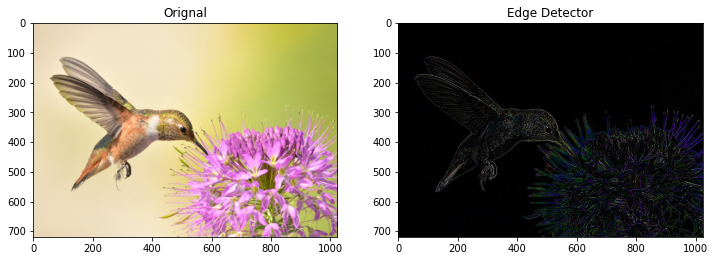

In [19]:
# Creating the Laplacian kernel(2d convolution matrix)
kernel2 = np.array([[-1, -1, -1],
                    [-1, 8, -1],
                    [-1, -1, -1]])

# Filters the images using the kernel
edge_image = cv2.filter2D(src=image, ddepth=-1, kernel=kernel2)

# Plots the original image and the filtered image using the function defined at the top
plot_image(image, edge_image , title_1="Orignal",title_2="Edge Detector")

### Median Filter

Median filters find the median of all the pixels under the kernel area and the central element is replaced with this median value.

In [29]:
# Adding Salt-and-Pepper noise
def add_salt_and_pepper_noise(image, prob=0.04):
    noisy_image = image.copy()
    num_salt = int(prob * image.size * 0.5)
    num_pepper = int(prob * image.size * 0.5)

    # Adding salt (white pixels)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape[:2]]
    noisy_image[coords[0], coords[1]] = [255, 255, 255]

    # Adding pepper (black pixels)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape[:2]]
    noisy_image[coords[0], coords[1]] = [0, 0, 0]

    return noisy_image

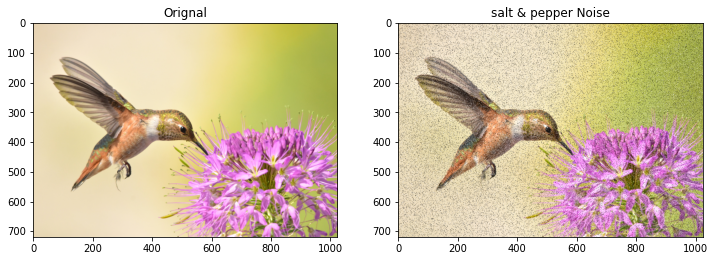

In [30]:
# Apply Salt-and-Pepper Noise
salt_pepper_image = add_salt_and_pepper_noise(image)

# Plots the original image and the filtered image using the function defined at the top
plot_image(image, salt_pepper_image , title_1="Orignal",title_2="salt & pepper Noise")

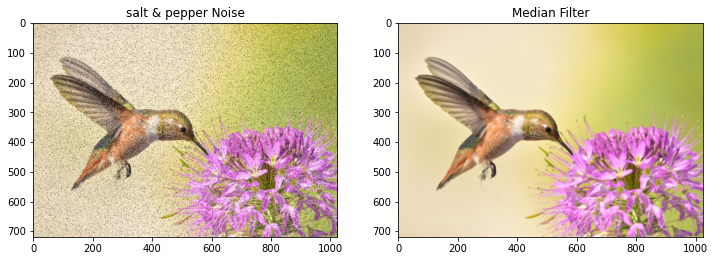

In [31]:
# Filter the image using Median Blur with a kernel of size 5
filtered_image = cv2.medianBlur(salt_pepper_image, 5)

# Plots the original image and the filtered image using the function defined at the top
plot_image(salt_pepper_image, filtered_image , title_1="salt & pepper Noise",title_2="Median Filter")

We can apply median filters to regular  images but let’s see how we can use  a median filter to improve segmentation.   Consider the cameraman example

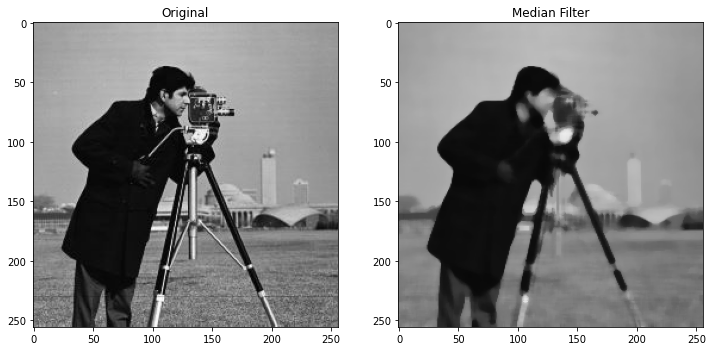

In [46]:
# Filter the image using Median Blur with a kernel of size 5
image1 = cv2.imread('lab7/cameraman.jpg')
test_image = cv2.medianBlur(image1, 7)

# Plots the original image and the filtered image using the function defined at the top
plot_image(image1, test_image , title_1="Original",title_2="Median Filter")

### Other types of noises
Speckle noise

Speckle noise is a type of image noise that appears as grainy texture, often seen in images from coherent imaging techniques like ultrasound or radar, and is considered "multiplicative" noise, meaning it affects the intensity of pixels proportionally to the original signal, unlike "salt and pepper" noise which randomly replaces individual pixels with extreme values (black or white), making it a form of "impulse" noise. 

In [139]:
# Adding Speckle noise
noise = np.random.normal(0, 0.5, image.shape).astype(np.float32)
speckleImg = image + image * noise
speckleImg = np.clip(speckleImg, 0, 255).astype(np.uint8)

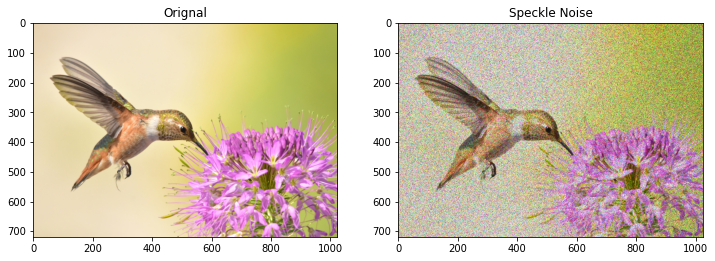

In [140]:
# Plots the original image and the filtered image using the function defined at the top
plot_image(image, speckleImg , title_1="Orignal",title_2="Speckle Noise")

### Poission Noise

"Poisson noise" refers to a type of noise that occurs when the number of photons detected by a camera sensor is small, and is often called "shot noise" as well.

This noise arises from the discrete nature of light, where photons arrive randomly at the sensor, following a Poisson distribution. 

Unlike Gaussian noise, which is signal-independent, Poisson noise is directly related to the signal intensity, meaning higher intensity pixels will have more noise. 

This noise model is commonly used in scenarios where low light conditions are present, like astronomy imaging, microscopy, and night vision cameras. 



In [141]:
# We can use skimage to add noise 

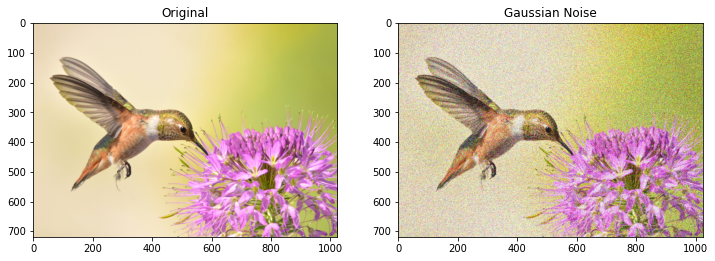

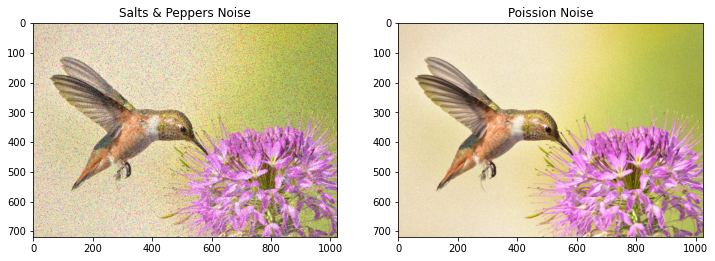

In [147]:
from skimage.util import random_noise

#Add Gaussian noise:
#g_noised_image = random_noise(image, mode='gaussian')*255
# random_noise by default is a gussian mode
g_noised_image = random_noise(image, var = 0.05)*255
g_noised_image = np.clip(g_noised_image, 0, 255).astype(np.uint8)
#Add salt&pepper noise:
sp_noised_image = random_noise(image, mode='s&p', amount=0.12)*255
sp_noised_image = np.clip(sp_noised_image, 0, 255).astype(np.uint8)

#Add Poisson noise:
poisson_noised_image =random_noise(image, mode='poisson')*255
poisson_noised_image = np.clip(poisson_noised_image, 0, 255).astype(np.uint8)


# Plots the original image and the filtered image using the function defined at the top
plot_image(image, g_noised_image , title_1="Original",title_2="Gaussian Noise")
plot_image(sp_noised_image, poisson_noised_image , title_1="Salts & Peppers Noise",title_2="Poission Noise")

### There are several smoothing/denosing techniques.  
Non-local Mean Denoising technique  
Principle: replacing the color of a pixel with an average of the colors of similar pixels. 

How it works:
1. Select a pixel:
For each pixel in the noisy image, calculate a small patch centered around it. 
2. Compare patches:
Compare the selected patch to every other patch in the image using a similarity metric (usually Euclidean distance). 
3. Assign weights:
Based on the calculated similarity, assign weights to each pixel in the image, where more similar patches get higher weights. 
4. Calculate weighted average:
Use the calculated weights to compute a weighted average of the pixel values from across the image, which becomes the denoised value for the target pixel. 

<code>cv2.fastNlMeansDenoisingColored(src[, dst[, h[, hColor[, templateWindowSize[, searchWindowSize]]]]])</code>

**Parameters:**  
**src** : Input image.  
**dst** : Output image.  
**h** : Parameter to regulate filter strength for luminance component. Bigger h value perfectly removes noise but also removes image details, smaller h value preserves details but also preserves some noise.  
**templateWindowSize** : Size in pixels of the template patch that is used to compute weights. Should be odd. Recommended value 7 pixels
**searchWindowSize** : Size in pixels of the window that is used to compute weighted average for given pixel. Should be odd. Affect performance linearly: greater searchWindowsSize - greater denoising time. Recommended value 21 pixels


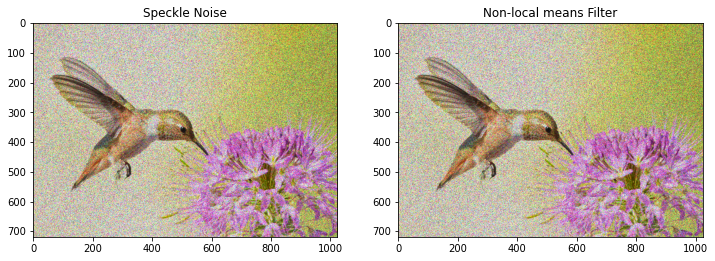

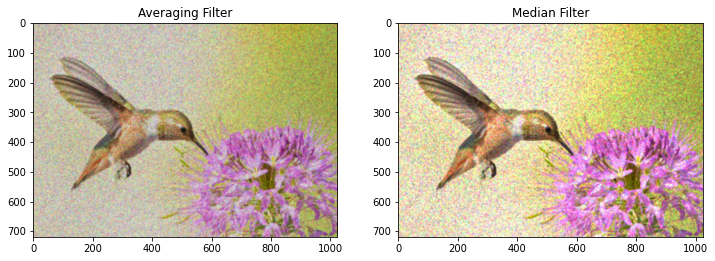

In [153]:
# Removing noise in image using Non-Local Means Denoising
filtered_image_1 = cv2.fastNlMeansDenoisingColored(speckleImg, None,8,7,15)

# Filter the image using Median Blur with a kernel of size 5
filtered_image = cv2.medianBlur(speckleImg, 5)

# Plots the images
plot_image(speckleImg, filtered_image_1, title_1="Speckle Noise",title_2="Non-local means Filter")

# Filter the image using OpenCV averaging filter of size 5
blur = cv2.blur(speckleImg,(5,5))

# Plots the images
plot_image(blur, filtered_image, title_1="Averaging Filter",title_2="Median Filter")

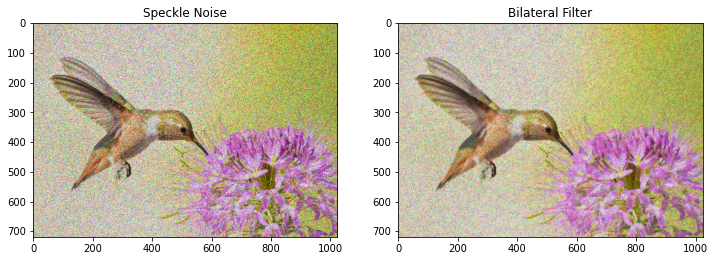

In [154]:
# Bilater filter
# Apply bilateral filter with d = 15,  
bilateral = cv2.bilateralFilter(speckleImg, 15, 75, 75) 
plot_image(speckleImg, bilateral, title_1="Speckle Noise",title_2="Bilateral Filter")

For denoising, it prefers techniques that can reduce noise in an image, while preserving edges.

An example is total variation denoising.This technique simultaneously preserve edges whilst smoothing away noise in flat regions, even at low signal-to-noise ratios.

Principle : minimize the total variation of the image.
(Images with spurious detail have high total variation overall image gradient magnitude is high.)

See more details in https://en.wikipedia.org/wiki/Total_variation_denoising

In [155]:
from skimage.restoration import denoise_tv_chambolle

denoised_image = denoise_tv_chambolle(sp_noised_image, weight=0.2, multichannel=True)
denoised_image = np.clip(denoised_image*255, 0, 255).astype(np.uint8)

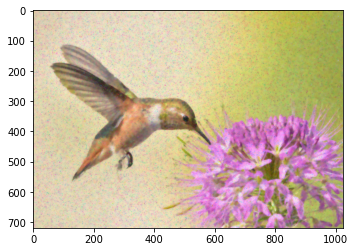

In [156]:
plt.imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))